<a href="https://colab.research.google.com/github/gleo1973/tp-laboratorio-mcag-1c2026/blob/main/Laboratorio_TP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Universidad de Buenos Aires · Facultad de Ciencias Económicas  
Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones*

# **Trabajo Práctico Grupal**
Exploración, análisis y presentación de datos reales asistida por IA  

## Análisis y comparación de los equipos de la Copa Mundial de Fútbol 2026.

*Por Leonardo Gomez, Fernando Morichetti y Carla Garibotti.*

---




In [1]:
#Importamos las librerías que vamos a utilizar

import pandas as pd #para manejo de archivos de datos
import numpy as np #para hacer operaciones matemáticas
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

In [2]:
#importamos la tabla con los paises que participan del torneo
#fuente: https://www.kaggle.com/datasets/harrachimustapha/fifa-world-cup-team-dataset

df_paises = pd.read_csv("datos/raw/paises.csv")

#importamos los paises con su codigo FIFA correspondiente
df_cod_paises = pd.read_excel("datos/raw/Codigo_de_Paises.xlsx")


In [3]:
# Se verifica que valores quedaron mal, permite identificar y aislar filas donde el nombre del equipo está corrupto para su correccion.
df_paises[df_paises['team'].str.contains(r'\?', na=False)]

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
45,2026,Cura?o,North America,0,55,39,12,10,10,0,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN


In [4]:
# Corregimos ese valor puntual
df_paises['team'] = df_paises['team'].replace('Cura?o', 'Curaçao')
df_paises[df_paises['team'].str.contains(r'\?', na=False)]

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist


In [5]:
# Definimos un Diccionario de traducción inglés → español (adaptá según tus datos)
traduccion = {
    'Argentina': 'Argentina',
    'Brazil': 'Brasil',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'England': 'Inglaterra',
    'Portugal': 'Portugal',
    'Netherlands': 'Países Bajos',
    'Uruguay': 'Uruguay',
    'Mexico': 'México',
    'United States': 'Estados Unidos',
    'South Korea': 'Corea del Sur',
    'Japan': 'Japón',
    'Morocco': 'Marruecos',
    'Senegal': 'Senegal',
    'Australia': 'Australia',
    'Switzerland': 'Suiza',
    'Croatia': 'Croacia',
    'Poland': 'Polonia',
    'Denmark': 'Dinamarca',
    'Belgium': 'Bélgica',
    'Colombia': 'Colombia',
    'Iran': 'Irán',
    'Turkey': 'Turquía',
    'Ecuador': 'Ecuador',
    'Austria': 'Austria',
    'Algeria': 'Argelia',
    'Egypt': 'Egipto',
    'Canada': 'Canadá',
    'Norway': 'Noruega',
    'Panama': 'Panamá',
    'Ivory Coast': 'Costa de Marfil',
    'Sweden': 'Suecia',
    'Paraguay': 'Paraguay',
    'Czech Republic': 'República Checa',
    'Scotland': 'Escocia',
    'Tunisia': 'Túnez',
    'DR Congo': 'República Democrática del Congo',
    'Uzbekistan': 'Uzbekistán',
    'Qatar': 'Catar',
    'Iraq': 'Irak',
    'South Africa': 'Sudáfrica',
    'Saudi Arabia': 'Arabia Saudita',
    'Jordan': 'Jordania',
    'Bosnia and Herzegovina': 'Bosnia y Herzegovina',
    'Cape Verde': 'Cabo Verde',
    'Ghana': 'Ghana',
    'Curaçao': 'Curazao',
    'Haiti': 'Haití',
    'New Zealand': 'Nueva Zelanda'
}

# Crear columna puente
df_paises['team_es'] = df_paises['team'].map(traduccion)

# Verificar si quedó alguno sin traducir
sin_traducir = df_paises[df_paises['team_es'].isna()]['team'].unique()
print("Sin traducir:", sin_traducir)

Sin traducir: []


In [6]:
# Merge para traer el código FIFA
df_paises = df_paises.merge(
    df_cod_paises,
    left_on='team_es',
    right_on='País',
    how='left'
)

# Verificar que no quedaron equipos sin código (Son los equipos que no estan en la Copa 2026)
sin_codigo = df_paises[df_paises['Código FIFA'].isna()][['team', 'team_es']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA:               team                          team_es
6      Netherlands                     Países Bajos
32  Czech Republic                  República Checa
35        DR Congo  República Democrática del Congo
37           Qatar                            Catar
39    South Africa                        Sudáfrica
46           Haiti                            Haití


In [7]:
# Eliminar columnas puente que ya no sirve, y las que no necesito
df_paises = df_paises.drop(columns=['#', 'team_es', 'País'])


In [8]:
df_paises.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          48 non-null     int64  
 1   team                             48 non-null     object 
 2   continent                        48 non-null     object 
 3   is_host                          48 non-null     int64  
 4   goals_scored_last_4y             48 non-null     int64  
 5   goals_received_last_4y           48 non-null     int64  
 6   wins_last_4y                     48 non-null     int64  
 7   losses_last_4y                   48 non-null     int64  
 8   draws_last_4y                    48 non-null     int64  
 9   world_cup_titles_before          48 non-null     int64  
 10  squad_total_market_value_eur     48 non-null     int64  
 11  fifa_rank_pre_tournament         48 non-null     int64  
 12  fifa_points_pre_tourname

columnas={"SEX":"GÉNERO","EDUCATION":"EDUCACION","AGE":"EDAD"}#creamos un diccionario
archivo_1.rename(columns=columnas,inplace=True)
archivo_1.head()

In [9]:
#filtramos las columnas que nos interesan
df_paises_f = df_paises.loc[:,["fifa_rank_pre_tournament","team","continent","squad_total_market_value_eur","fifa_points_pre_tournament"]].copy()

#armamos un diccionario para renombrar las columnas
columnas = {"fifa_rank_pre_tournament":"ranking_FIFA",
            "team":"pais",
            "continent":"continente",
            "squad_total_market_value_eur":"valor_en_euros",
            "fifa_points_pre_tournament":"puntos_FIFA"
            }
df_paises_f.rename(columns=columnas,inplace=True)

In [10]:
df_paises_f.dtypes

ranking_FIFA        int64
pais               object
continente         object
valor_en_euros      int64
puntos_FIFA       float64
dtype: object

Text(0, 0.5, 'Puntos FIFA')

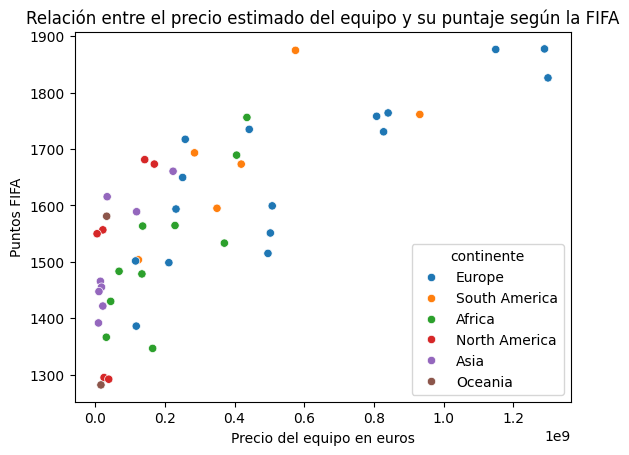

In [11]:
sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue='continente', #el color lo da el continente
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA")
plt.xlabel('Precio del equipo en euros')
plt.ylabel("Puntos FIFA")

Text(0, 0.5, 'Puntos FIFA')

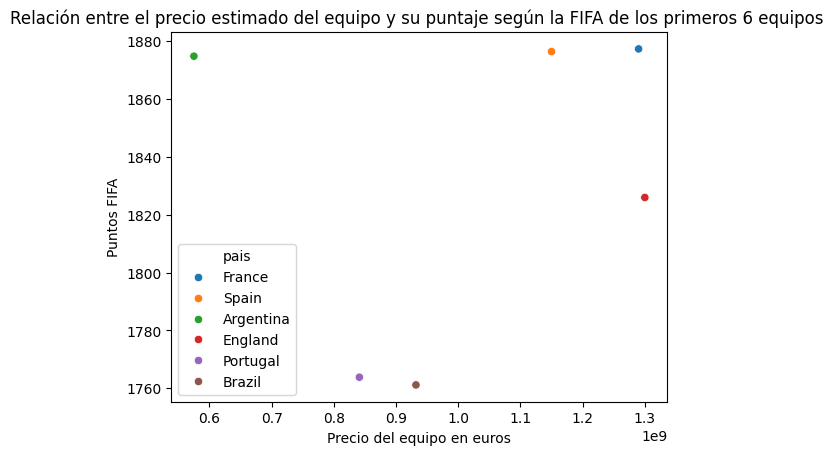

In [12]:
sns.scatterplot(
    data=df_paises_f.head(6), #detalle de los primeros 6 paises
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue="pais", #el color lo da el pais
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA de los primeros 6 equipos ")
plt.xlabel('Precio del equipo en euros')
plt.ylabel("Puntos FIFA")